In [32]:
import matplotlib.pyplot as plt
import numpy
import pandas

plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams["font.family"] = 'serif'
plt.rcParams["font.size"] = 8
plt.rcParams['figure.figsize'] = (3.5, 2.5)

In [33]:
DATASET = "PCQM4Mv2"
PATH  = "pcqm4mv2-pe.csv"

/home/jlagesse/.tmp/ipykernel_287882/262794516.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=architectures, showfliers=False, patch_artist=True, medianprops=dict(linestyle="None"))


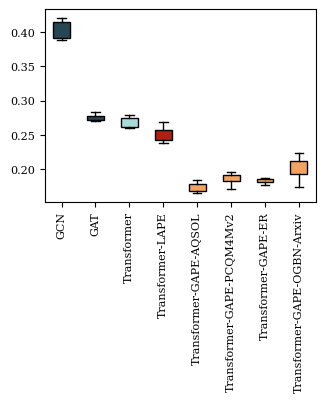

In [34]:
raw_df = pandas.read_csv(PATH)[["Name", "loss/train", "loss/val"]]
architectures = [
    "GCN",
    "GAT",
    "Transformer",
    "Transformer-LAPE",
    "Transformer-GAPE-AQSOL",
    "Transformer-GAPE-PCQM4Mv2",
    "Transformer-GAPE-ER",
    "Transformer-GAPE-OGBN-Arxiv",
]
colors = [
    "#264653",
    "#264653",
    "#a8dadc",
    "#ae2012",
    "#f4a261",
    "#f4a261",
    "#f4a261",
    "#f4a261"
]
data = [
    raw_df[raw_df["Name"] == architecture]["loss/val"].to_numpy()
    for architecture in architectures
]
box = plt.boxplot(data, labels=architectures, showfliers=False, patch_artist=True, medianprops=dict(linestyle="None"))
for (patch, color) in zip(box["boxes"], colors):
    patch.set_facecolor(color)
plt.xticks(rotation=90)
plt.show()

In [35]:
mean = raw_df.groupby(["Name"])["loss/val"].mean()
std = raw_df.groupby(["Name"])["loss/val"].std()
table = pandas.DataFrame(index=architectures, columns=["mean", "std"])
table["mean"] = mean
table["std"] = std
print(table)

                                 mean       std
GCN                          0.402886  0.011896
GAT                          0.277003  0.008131
Transformer                  0.290299  0.067288
Transformer-LAPE             0.251033  0.011525
Transformer-GAPE-AQSOL       0.175057  0.011427
Transformer-GAPE-PCQM4Mv2    0.186409  0.007873
Transformer-GAPE-ER          0.182194  0.009954
Transformer-GAPE-OGBN-Arxiv  0.199347  0.017507
